# Deep Learning-Based Classification of Imbalanced Wireless Capsule Endoscopy (WCE) Datasets

**Objective:** Design, train, and evaluate deep learning models for gastrointestinal disease classification using imbalanced WCE datasets, while applying under-sampling, data augmentation-based over-sampling, transfer learning, and intelligent learning rate control.

**Framework:** PyTorch

**Models:** EfficientNet-B0, MobileNetV3-Small, InceptionV3

---
## Setup and Imports

In [1]:
import os
import shutil
import random
import copy
import warnings
import tarfile
import zipfile
import gc
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# Check device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


---
## Configuration

In [ ]:
# ============================================================
# CONFIGURATION - Auto-detect/extract dataset in this workspace
# ============================================================

DATASET_ZIP = './kvasir-capsule-labeled-images.zip' 
WORKING_DIR = './working'                           
UNDERSAMPLED_DIR = os.path.join(WORKING_DIR, 'undersampled')
AUGMENTED_DIR = os.path.join(WORKING_DIR, 'augmented')
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 5
UNDERSAMPLE_THRESHOLD = 200
NUM_WORKERS = 0 if os.name == 'nt' else 2

IMAGE_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

def _flatten_nested_images(class_dir):
    """Move images from nested folders into class_dir root if needed."""
    direct_images = [
        f for f in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, f)) and f.lower().endswith(IMAGE_EXTS)
    ]
    if direct_images:
        return

    nested_files = []
    for root, _, files in os.walk(class_dir):
        for file_name in files:
            if file_name.lower().endswith(IMAGE_EXTS):
                nested_files.append(os.path.join(root, file_name))

    for src_file in nested_files:
        base_name = os.path.basename(src_file)
        dst_file = os.path.join(class_dir, base_name)
        if os.path.abspath(src_file) == os.path.abspath(dst_file):
            continue

        # Avoid overwrite if duplicate file names exist.
        if os.path.exists(dst_file):
            stem, ext = os.path.splitext(base_name)
            i = 1
            while os.path.exists(dst_file):
                dst_file = os.path.join(class_dir, f'{stem}_{i}{ext}')
                i += 1

        shutil.move(src_file, dst_file)

def ensure_dataset_available(zip_path=DATASET_ZIP, working_dir=WORKING_DIR):
    """Prepare dataset folder with class-wise image subfolders and return its path."""
    os.makedirs(working_dir, exist_ok=True)
    prepared_dir = os.path.join(working_dir, 'kvasir_capsule_images')

    # If dataset is already prepared, ensure it is flattened for downstream cells.
    if os.path.isdir(prepared_dir) and any(os.scandir(prepared_dir)):
        for class_name in os.listdir(prepared_dir):
            class_dir = os.path.join(prepared_dir, class_name)
            if os.path.isdir(class_dir):
                _flatten_nested_images(class_dir)
        return prepared_dir

    if not os.path.isfile(zip_path):
        raise FileNotFoundError(
            f'Dataset zip not found: {zip_path}. Place it in the project root or update DATASET_ZIP.'
        )

    print('Extracting dataset zip (first run only)...')
    extracted_root = os.path.join(working_dir, 'kvasir_raw')
    os.makedirs(extracted_root, exist_ok=True)

    if not any(os.scandir(extracted_root)):
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extracted_root)

    labelled_dir = os.path.join(extracted_root, 'labelled_images')
    if not os.path.isdir(labelled_dir):
        raise FileNotFoundError(
            f"Expected 'labelled_images' inside extracted zip at: {labelled_dir}"
        )

    os.makedirs(prepared_dir, exist_ok=True)
    tar_archives = [f for f in os.listdir(labelled_dir) if f.endswith('.tar.gz')]

    for archive_name in tar_archives:
        class_name = archive_name.replace('.tar.gz', '')
        class_dir = os.path.join(prepared_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        # Skip extraction if this class already has image files.
        existing_images = [
            f for f in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, f)) and f.lower().endswith(IMAGE_EXTS)
        ]
        if existing_images:
            continue

        archive_path = os.path.join(labelled_dir, archive_name)
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(class_dir)

        _flatten_nested_images(class_dir)

    return prepared_dir

DATASET_DIR = ensure_dataset_available()
print(f'Dataset directory: {os.path.abspath(DATASET_DIR)}')
print(f'Results directory: {os.path.abspath(RESULTS_DIR)}')
print(f'DataLoader workers: {NUM_WORKERS}')

Extracting dataset zip (first run only)...
Dataset directory: c:\Users\tarun\OneDrive\Desktop\Project-DL\working\kvasir_capsule_images
Results directory: c:\Users\tarun\OneDrive\Desktop\Project-DL\results
DataLoader workers: 0


---
# Task 1: Dataset Exploration and Imbalance Analysis

In [3]:
# ============================================================
# Task 1.1: Load dataset and count images per class
# ============================================================

def get_class_distribution(dataset_dir):
    """Count images per class from a directory with class subfolders."""
    class_counts = {}
    for class_name in sorted(os.listdir(dataset_dir)):
        class_path = os.path.join(dataset_dir, class_name)
        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
            ])
            class_counts[class_name] = count
    return class_counts

class_distribution = get_class_distribution(DATASET_DIR)
class_names = list(class_distribution.keys())
class_counts = list(class_distribution.values())
num_classes = len(class_names)

print(f'Number of classes: {num_classes}')
print(f'Total images: {sum(class_counts)}')
print(f'\nClass-wise distribution:')
for name, count in sorted(class_distribution.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name}: {count} images')

Number of classes: 14
Total images: 47238

Class-wise distribution:
  normal_clean_mucosa: 34338 images
  ileocecal_valve: 4189 images
  reduced_mucosal_view: 2906 images
  pylorus: 1529 images
  angiectasia: 866 images
  ulcer: 854 images
  foreign_body: 776 images
  lymphangiectasia: 592 images
  erosion: 506 images
  blood_fresh: 446 images
  erythema: 159 images
  polyp: 55 images
  blood_hematin: 12 images
  ampulla_of_vater: 10 images


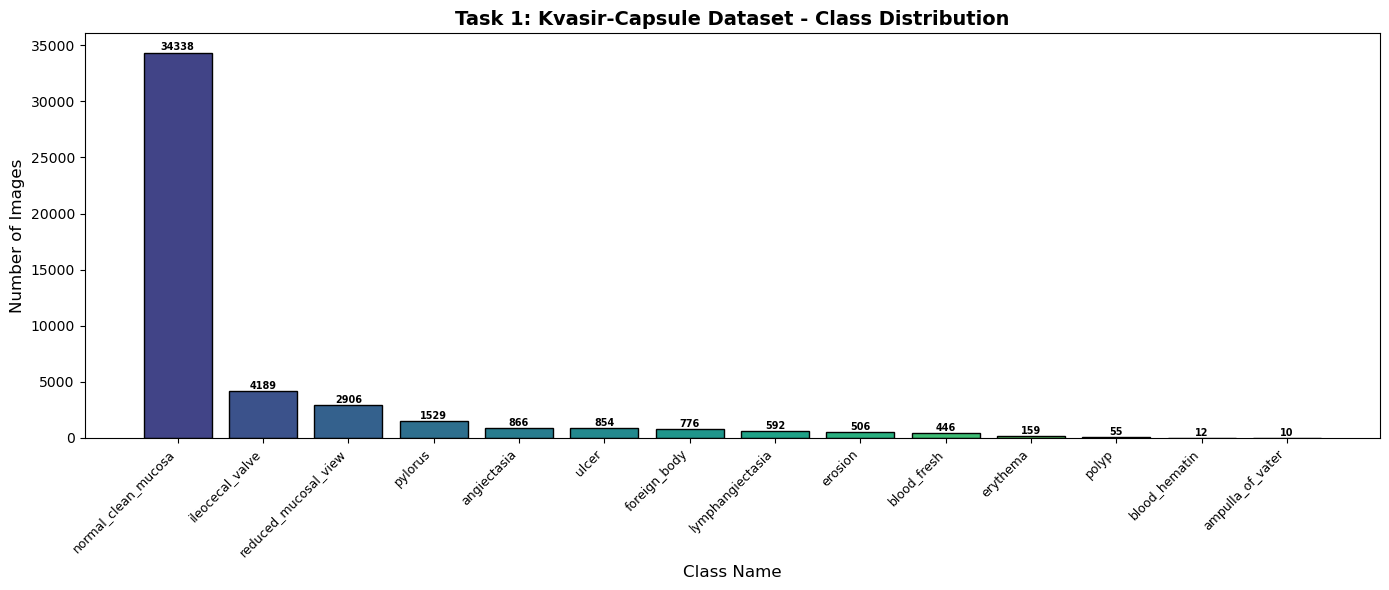

In [8]:
# ============================================================
# Task 1.2: Plot class-wise image distribution (Bar Chart)
# ============================================================

sorted_items = sorted(class_distribution.items(), key=lambda x: x[1], reverse=True)
sorted_names = [item[0] for item in sorted_items]
sorted_counts = [item[1] for item in sorted_items]

plt.figure(figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_names)))
bars = plt.bar(range(len(sorted_names)), sorted_counts, color=colors, edgecolor='black')
plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right', fontsize=9)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Task 1: Kvasir-Capsule Dataset - Class Distribution', fontsize=14, fontweight='bold')

for bar, count in zip(bars, sorted_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('task1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# Task 1.3: Identify majority and minority classes
# ============================================================

median_count = np.median(sorted_counts)
majority_classes = {k: v for k, v in class_distribution.items() if v > median_count}
minority_classes = {k: v for k, v in class_distribution.items() if v <= median_count}

print('MAJORITY CLASSES (above median):')
for name, count in sorted(majority_classes.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name}: {count}')

print(f'\nMINORITY CLASSES (at or below median):')
for name, count in sorted(minority_classes.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name}: {count}')

imbalance_ratio = max(class_counts) / max(min(class_counts), 1)
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.1f}x')
print(f'Median class size: {median_count:.0f}')

MAJORITY CLASSES (above median):
  normal_clean_mucosa: 34338
  ileocecal_valve: 4189
  reduced_mucosal_view: 2906
  pylorus: 1529
  angiectasia: 866
  ulcer: 854
  foreign_body: 776

MINORITY CLASSES (at or below median):
  lymphangiectasia: 592
  erosion: 506
  blood_fresh: 446
  erythema: 159
  polyp: 55
  blood_hematin: 12
  ampulla_of_vater: 10

Imbalance ratio (max/min): 3433.8x
Median class size: 684


### Task 1.4: Why Class Imbalance is Critical in Medical Diagnosis

Class imbalance is a significant challenge in medical image classification because models tend to develop a strong bias toward the majority class. In the case of WCE datasets, common findings such as normal mucosa vastly outnumber rare but clinically critical conditions like polyps or bleeding. A model trained on such skewed data may achieve high overall accuracy by simply predicting the dominant class, while completely failing to detect the minority conditions that require urgent medical attention. In a clinical setting, missing a rare disease (false negative) can delay treatment and harm patient outcomes. Therefore, addressing class imbalance through techniques like under-sampling, augmentation-based over-sampling, and class-weighted losses is essential to build models that are both sensitive and reliable across all diagnostic categories.

---
# Task 2: Under-Sampling (Majority Class Control)

### Task 2 Technique Summary (SAFE Under-Sampling)

We implemented a **two-stage SAFE under-sampling pipeline** to reduce redundancy in video-derived frames while preserving medically useful diversity:

1. **Temporal buffering for very large classes (>1000):**
   - Randomized temporal sampling (stride-based ) reduces frames to an intermediate buffer (~600).
2. **Diversity selection to 200 (k-center greedy):**
   - A pretrained CNN (ResNet50) features extracts embeddings.
   - Greedy max-min (k-center) selects the most diverse frames.
3. **Medium-size classes (201 to 1000):**
   - Direct diversity-based selection to 200.
4. **Small classes (<=200):**
   - Kept unchanged.

This design avoids naive random dropping and keeps broad temporal + visual coverage.

In [ ]:
# ============================================================
# Task 2.1: SAFE under-sampling for video-derived frames
#   Step 1: Temporal buffering to ~600 samples (for very large classes)
#   Step 2: Diversity selection to exactly 200 (k-center greedy)
# ============================================================

def _list_images(class_dir):
    return sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
    ])


def _ensure_count(indices, total_count, target_count, rng):
    """Trim/pad index list to target_count while keeping randomness."""
    if target_count <= 0:
        return []

    unique_indices = sorted(set(int(i) for i in indices if 0 <= int(i) < total_count))

    if len(unique_indices) >= target_count:
        # Uniformly trim if we have too many.
        pick_pos = np.linspace(0, len(unique_indices) - 1, target_count, dtype=int)
        return [unique_indices[i] for i in pick_pos]

    # Pad using random indices not already selected.
    remaining = [i for i in range(total_count) if i not in set(unique_indices)]
    needed = target_count - len(unique_indices)

    if needed > 0 and remaining:
        add_count = min(needed, len(remaining))
        unique_indices.extend(rng.sample(remaining, add_count))
        needed = target_count - len(unique_indices)

    # If still short (rare), allow replacement from full range.
    while needed > 0:
        unique_indices.append(rng.randrange(total_count))
        needed -= 1

    return sorted(unique_indices)


def safe_temporal_sampling(frames, target_count=600, method='segment', rng=None):
    """
    Stage-1 buffering sampler.
    - method='stride': random-offset stride sampling.
    Returns approximately/exactly target_count frames (clipped by available data).
    """
    rng = rng or random.Random(SEED)
    n = len(frames)
    if n <= target_count:
        return list(frames)

    target_count = min(target_count, n)

    if method == 'stride':
        stride = max(1, n // target_count)
        start_index = rng.randint(0, stride - 1) if stride > 1 else 0
        idx = list(range(start_index, n, stride))
        idx = _ensure_count(idx, n, target_count, rng)
        return [frames[i] for i in idx]

    # Preferred: segment-based randomized temporal coverage.
    boundaries = np.linspace(0, n, target_count + 1, dtype=int)
    idx = []
    for i in range(target_count):
        lo, hi = boundaries[i], boundaries[i + 1]
        if hi <= lo:
            idx.append(min(lo, n - 1))
        else:
            idx.append(rng.randrange(lo, hi))

    idx = _ensure_count(idx, n, target_count, rng)
    return [frames[i] for i in idx]


def build_feature_extractor(backbone='resnet50', device=DEVICE):
    """Create pretrained CNN feature extractor for embedding generation."""
    backbone = backbone.lower()

    if backbone == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier = nn.Identity()
    else:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Identity()

    model = model.to(device)
    model.eval()
    return model


def extract_image_embeddings(image_paths, feature_model, device=DEVICE, batch_size=64):
    """Extract L2-normalized feature embeddings for a list of image paths."""

    class _ImagePathDataset(Dataset):
        def __init__(self, paths, transform):
            self.paths = paths
            self.transform = transform

        def __len__(self):
            return len(self.paths)

        def __getitem__(self, idx):
            img = Image.open(self.paths[idx]).convert('RGB')
            return self.transform(img)

    preprocess = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    ds = _ImagePathDataset(image_paths, preprocess)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == 'cuda')
    )

    chunks = []
    with torch.no_grad():
        for images in dl:
            images = images.to(device, non_blocking=True)
            feats = feature_model(images)
            feats = feats.view(feats.size(0), -1)
            chunks.append(feats)

    emb = torch.cat(chunks, dim=0)
    emb = nn.functional.normalize(emb, p=2, dim=1)
    return emb


def kcenter_greedy_select(embeddings, k, rng=None):
    """Greedy max-min diversity sampling (k-center) over embeddings."""
    rng = rng or random.Random(SEED)
    n = embeddings.size(0)
    if n <= k:
        return list(range(n))

    # Start from a random point for randomized but reproducible behavior.
    first = rng.randrange(n)
    selected = [first]

    # Track each point's distance to nearest selected center.
    min_dist = torch.cdist(embeddings, embeddings[[first]]).squeeze(1)

    for _ in range(1, k):
        next_idx = torch.argmax(min_dist).item()
        selected.append(next_idx)
        dist_to_new = torch.cdist(embeddings, embeddings[[next_idx]]).squeeze(1)
        min_dist = torch.minimum(min_dist, dist_to_new)

    return selected


def apply_undersampling(
    src_dir,
    dst_dir,
    target_count=200,
    majority_threshold=1000,
    temporal_buffer=600,
    temporal_method='segment',
    feature_backbone='resnet50',
    feature_batch_size=64,
    seed=SEED,
):
    """
    SAFE under-sampling pipeline.

    Rules:
    - If class count > majority_threshold: temporal buffer -> diversity to exactly target_count.
    - If target_count < class count <= majority_threshold: diversity to exactly target_count.
    - If class count <= target_count: keep all samples.
    """
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir, exist_ok=True)

    rng = random.Random(seed)
    feature_model = build_feature_extractor(backbone=feature_backbone, device=DEVICE)

    stats = {}

    for class_name in sorted(os.listdir(src_dir)):
        class_src = os.path.join(src_dir, class_name)
        if not os.path.isdir(class_src):
            continue

        class_dst = os.path.join(dst_dir, class_name)
        os.makedirs(class_dst, exist_ok=True)

        images = _list_images(class_src)
        original_count = len(images)

        if original_count > majority_threshold:
            # Step 1: Temporal buffering to ~600.
            buffered_frames = safe_temporal_sampling(
                images,
                target_count=min(temporal_buffer, original_count),
                method=temporal_method,
                rng=rng,
            )

            # Step 2: Diversity selection to exactly 200.
            buffered_paths = [os.path.join(class_src, f) for f in buffered_frames]
            embeddings = extract_image_embeddings(
                buffered_paths,
                feature_model,
                device=DEVICE,
                batch_size=feature_batch_size,
            )
            chosen_idx = kcenter_greedy_select(embeddings, k=target_count, rng=rng)
            selected = [buffered_frames[i] for i in chosen_idx]
            strategy = f'safe_temporal_{temporal_method}+kcenter'
            temporal_count = len(buffered_frames)

        elif original_count > target_count:
            # Apply diversity-only under-sampling for medium-size classes (200, 1000].
            full_paths = [os.path.join(class_src, f) for f in images]
            embeddings = extract_image_embeddings(
                full_paths,
                feature_model,
                device=DEVICE,
                batch_size=feature_batch_size,
            )
            chosen_idx = kcenter_greedy_select(embeddings, k=target_count, rng=rng)
            selected = [images[i] for i in chosen_idx]
            strategy = 'kcenter_only'
            temporal_count = original_count

        else:
            selected = images
            strategy = 'keep_low_count'
            temporal_count = original_count

        # Copy selected images.
        for img_name in selected:
            shutil.copy2(os.path.join(class_src, img_name), os.path.join(class_dst, img_name))

        stats[class_name] = {
            'original': original_count,
            'temporal_buffer': temporal_count,
            'after': len(selected),
            'strategy': strategy,
        }

    return stats


# Run SAFE under-sampling
undersample_stats = apply_undersampling(
    DATASET_DIR,
    UNDERSAMPLED_DIR,
    target_count=200,
    majority_threshold=1000,
    temporal_buffer=600,
    temporal_method='segment',   # 'segment' preferred, 'stride' optional
    feature_backbone='resnet50',
    feature_batch_size=64,
    seed=SEED,
)

print('SAFE under-sampling summary:\n')
total_original = 0
total_after = 0
for name, s in sorted(undersample_stats.items()):
    print(
        f"  {name}: {s['original']} -> {s['temporal_buffer']} -> {s['after']} "
        f"[{s['strategy']}]"
    )
    total_original += s['original']
    total_after += s['after']

print(f'\nTotal: {total_original} -> {total_after} images')
print(f"Data loss: {total_original - total_after} images ({(total_original - total_after) / max(total_original, 1) * 100:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\tarun/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:12<00:00, 8.07MB/s]


SAFE under-sampling summary:

  ampulla_of_vater: 10 -> 10 -> 10 [keep_low_count]
  angiectasia: 866 -> 866 -> 200 [kcenter_only]
  blood_fresh: 446 -> 446 -> 200 [kcenter_only]
  blood_hematin: 12 -> 12 -> 12 [keep_low_count]
  erosion: 506 -> 506 -> 200 [kcenter_only]
  erythema: 159 -> 159 -> 159 [keep_low_count]
  foreign_body: 776 -> 776 -> 200 [kcenter_only]
  ileocecal_valve: 4189 -> 600 -> 200 [safe_temporal_segment+kcenter]
  lymphangiectasia: 592 -> 592 -> 200 [kcenter_only]
  normal_clean_mucosa: 34338 -> 600 -> 200 [safe_temporal_segment+kcenter]
  polyp: 55 -> 55 -> 55 [keep_low_count]
  pylorus: 1529 -> 600 -> 200 [safe_temporal_segment+kcenter]
  reduced_mucosal_view: 2906 -> 600 -> 200 [safe_temporal_segment+kcenter]
  ulcer: 854 -> 854 -> 200 [kcenter_only]

Total: 47238 -> 2236 images
Data loss: 45002 images (95.3%)


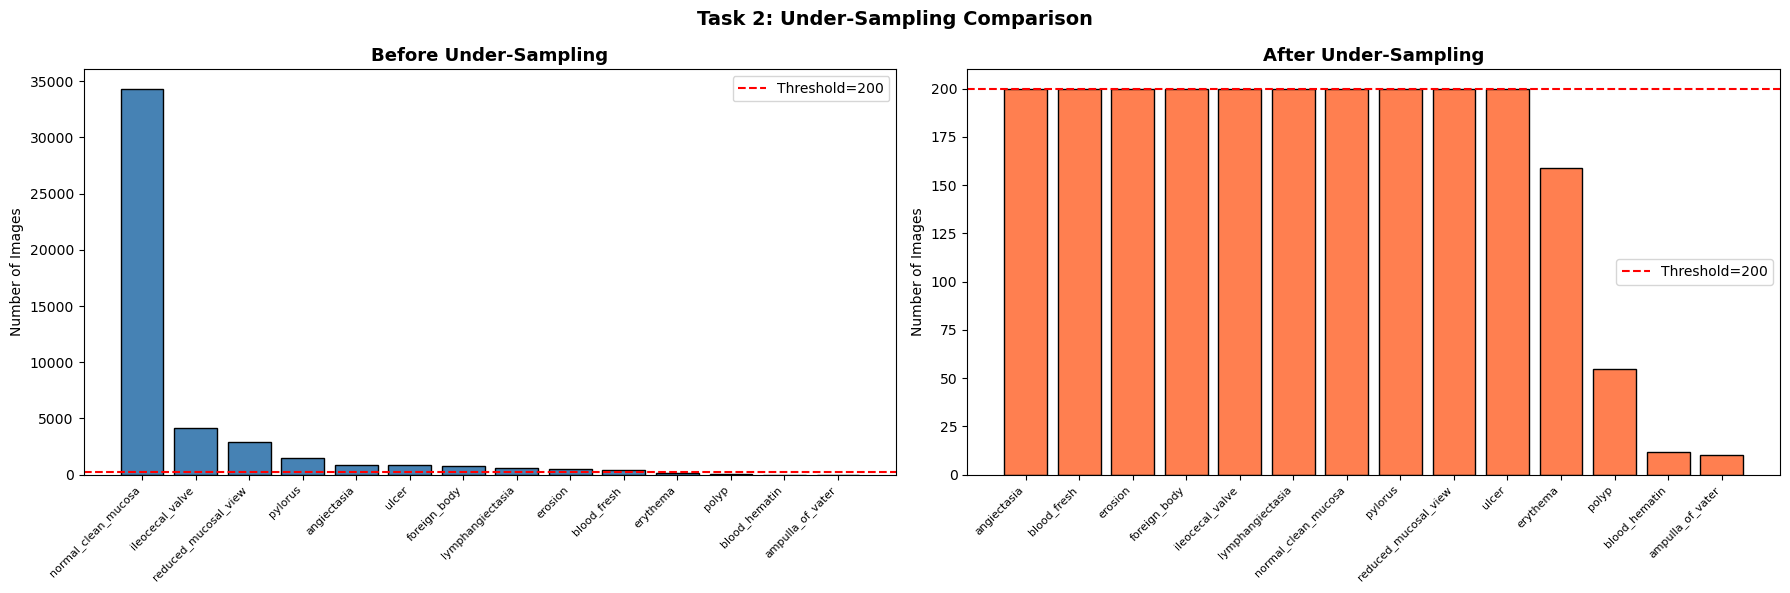


Observation: Under-sampling reduces majority classes to the threshold, preventing
model bias toward common conditions. However, it discards potentially useful data.
Minority classes are preserved entirely to avoid losing rare but critical samples.


In [10]:
# ============================================================
# Task 2.2: Plot updated class distribution after under-sampling
# ============================================================

undersampled_dist = get_class_distribution(UNDERSAMPLED_DIR)
us_sorted = sorted(undersampled_dist.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before under-sampling
axes[0].bar(range(len(sorted_names)), sorted_counts, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(sorted_names)))
axes[0].set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Before Under-Sampling', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].axhline(y=UNDERSAMPLE_THRESHOLD, color='red', linestyle='--', label=f'Threshold={UNDERSAMPLE_THRESHOLD}')
axes[0].legend()

# After under-sampling
us_names = [item[0] for item in us_sorted]
us_counts = [item[1] for item in us_sorted]
axes[1].bar(range(len(us_names)), us_counts, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(us_names)))
axes[1].set_xticklabels(us_names, rotation=45, ha='right', fontsize=8)
axes[1].set_title('After Under-Sampling', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Images')
axes[1].axhline(y=UNDERSAMPLE_THRESHOLD, color='red', linestyle='--', label=f'Threshold={UNDERSAMPLE_THRESHOLD}')
axes[1].legend()

plt.suptitle('Task 2: Under-Sampling Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_undersampling.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: Under-sampling reduces majority classes to the threshold, preventing')
print('model bias toward common conditions. However, it discards potentially useful data.')
print('Minority classes are preserved entirely to avoid losing rare but critical samples.')

---
# Task 3: Data Augmentation-Based Over-Sampling

### Task 3 Technique Summary (Controlled Augmentation)

We implemented a **controlled augmentation pipeline** to make each class reach exactly **200 samples**:

1. **Augment only minority classes (<200).**
2. For each class, compute required samples: **K = 200 - N**.
3. Use **7 single-technique augmentations** (no chaining):
   - Horizontal Flip
   - Rotation (±20°)
   - Translation (up to 0.2)
   - Zoom (0.8 to 1.2)
   - Color Jitter (brightness/contrast)
   - Gaussian Blur
   - Random Erasing
4. **Controlled distribution per technique:**
   - `per_technique = K // 7`, `remainder = K % 7`
   - First `remainder` techniques generate one extra sample.
5. **Diversity control:**
   - Source images are selected with usage balancing to avoid repeatedly augmenting the same image too often.
6. **Output logging:**
   - Per class: original count, final count, and `technique -> generated count` log.

This ensures balanced class size while preserving augmentation variety and control.

In [12]:
# ============================================================
# Task 3.1: Controlled augmentation to make every class exactly 200
#   - Augment only classes with < 200 samples
#   - Use single-technique transforms (no chaining)
#   - Controlled per-technique allocation
# ============================================================

# Single-technique augmentation operators
AUG_TECHNIQUES = {
    'horizontal_flip': transforms.RandomHorizontalFlip(p=1.0),
    'rotation_pm20': transforms.RandomRotation(degrees=20),
    'translation_0p2': transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    'zoom_0p8_to_1p2': transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    'color_jitter': transforms.ColorJitter(brightness=0.25, contrast=0.25),
    'gaussian_blur': transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    'random_erasing': transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomErasing(p=1.0, scale=(0.02, 0.20), ratio=(0.3, 3.3), value='random'),
        transforms.ToPILImage(),
    ]),
}


def _list_images(class_dir):
    return sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
    ])


def _technique_allocation(k, technique_names):
    """Controlled distribution: first remainder techniques get +1 sample."""
    t = len(technique_names)
    per_technique = k // t
    remainder = k % t

    allocation = {}
    for i, name in enumerate(technique_names):
        allocation[name] = per_technique + (1 if i < remainder else 0)
    return allocation


def _pick_source_images_balanced(image_names, count, usage_counter, rng):
    """Pick source images while minimizing repeated use of same image."""
    picked = []
    for _ in range(count):
        min_use = min(usage_counter[n] for n in image_names)
        candidates = [n for n in image_names if usage_counter[n] == min_use]
        choice = rng.choice(candidates)
        usage_counter[choice] += 1
        picked.append(choice)
    return picked


def _apply_single_augmentation(image, technique_name):
    """Apply exactly one augmentation technique to an RGB PIL image."""
    aug = AUG_TECHNIQUES[technique_name]
    return aug(image)


def augment_to_target_count(src_dir, dst_dir, target_count=200, seed=SEED):
    """
    Controlled augmentation pipeline:
    - Copy originals
    - For classes with N < target_count, generate K = target_count - N using
      per-technique controlled allocation.
    - No augmentation for classes with N >= target_count.
    - Guarantees final class size == target_count.
    """
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir, exist_ok=True)

    rng = random.Random(seed)
    technique_names = list(AUG_TECHNIQUES.keys())

    stats = {}

    for class_name in sorted(os.listdir(src_dir)):
        class_src = os.path.join(src_dir, class_name)
        if not os.path.isdir(class_src):
            continue

        class_dst = os.path.join(dst_dir, class_name)
        os.makedirs(class_dst, exist_ok=True)

        images = _list_images(class_src)
        n = len(images)

        technique_log = {name: 0 for name in technique_names}

        # Keep at most target_count originals (safety for unexpected oversize classes).
        if n > target_count:
            kept_originals = rng.sample(images, target_count)
        else:
            kept_originals = images

        for img_name in kept_originals:
            shutil.copy2(os.path.join(class_src, img_name), os.path.join(class_dst, img_name))

        current_count = len(kept_originals)

        # Augment only if below target_count.
        if current_count < target_count and current_count > 0:
            k = target_count - current_count
            allocation = _technique_allocation(k, technique_names)
            usage_counter = {name: 0 for name in kept_originals}

            for tech_name in technique_names:
                num_to_generate = allocation[tech_name]
                if num_to_generate <= 0:
                    continue

                selected_sources = _pick_source_images_balanced(
                    kept_originals,
                    num_to_generate,
                    usage_counter,
                    rng,
                )

                for j, src_img_name in enumerate(selected_sources):
                    src_path = os.path.join(class_src, src_img_name)
                    img = Image.open(src_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                    aug_img = _apply_single_augmentation(img, tech_name)

                    out_name = f'aug_{tech_name}_{j}_{src_img_name}'
                    aug_img.save(os.path.join(class_dst, out_name))

                technique_log[tech_name] += num_to_generate

        final_count = len(_list_images(class_dst))

        stats[class_name] = {
            'original': n,
            'kept_originals': current_count,
            'augmented_total': max(0, target_count - current_count),
            'final': final_count,
            'technique_log': technique_log,
        }

    return stats


augment_stats = augment_to_target_count(
    UNDERSAMPLED_DIR,
    AUGMENTED_DIR,
    target_count=200,
    seed=SEED,
)

print('Controlled augmentation results:\n')
for class_name, s in sorted(augment_stats.items()):
    print(f"{class_name}: {s['original']} -> {s['final']} (kept originals: {s['kept_originals']})")
    for tech_name, count in s['technique_log'].items():
        print(f'  {tech_name} -> {count}')
    print('')

Controlled augmentation results:

ampulla_of_vater: 10 -> 200 (kept originals: 10)
  horizontal_flip -> 28
  rotation_pm20 -> 27
  translation_0p2 -> 27
  zoom_0p8_to_1p2 -> 27
  color_jitter -> 27
  gaussian_blur -> 27
  random_erasing -> 27

angiectasia: 200 -> 200 (kept originals: 200)
  horizontal_flip -> 0
  rotation_pm20 -> 0
  translation_0p2 -> 0
  zoom_0p8_to_1p2 -> 0
  color_jitter -> 0
  gaussian_blur -> 0
  random_erasing -> 0

blood_fresh: 200 -> 200 (kept originals: 200)
  horizontal_flip -> 0
  rotation_pm20 -> 0
  translation_0p2 -> 0
  zoom_0p8_to_1p2 -> 0
  color_jitter -> 0
  gaussian_blur -> 0
  random_erasing -> 0

blood_hematin: 12 -> 200 (kept originals: 12)
  horizontal_flip -> 27
  rotation_pm20 -> 27
  translation_0p2 -> 27
  zoom_0p8_to_1p2 -> 27
  color_jitter -> 27
  gaussian_blur -> 27
  random_erasing -> 26

erosion: 200 -> 200 (kept originals: 200)
  horizontal_flip -> 0
  rotation_pm20 -> 0
  translation_0p2 -> 0
  zoom_0p8_to_1p2 -> 0
  color_jitter ->

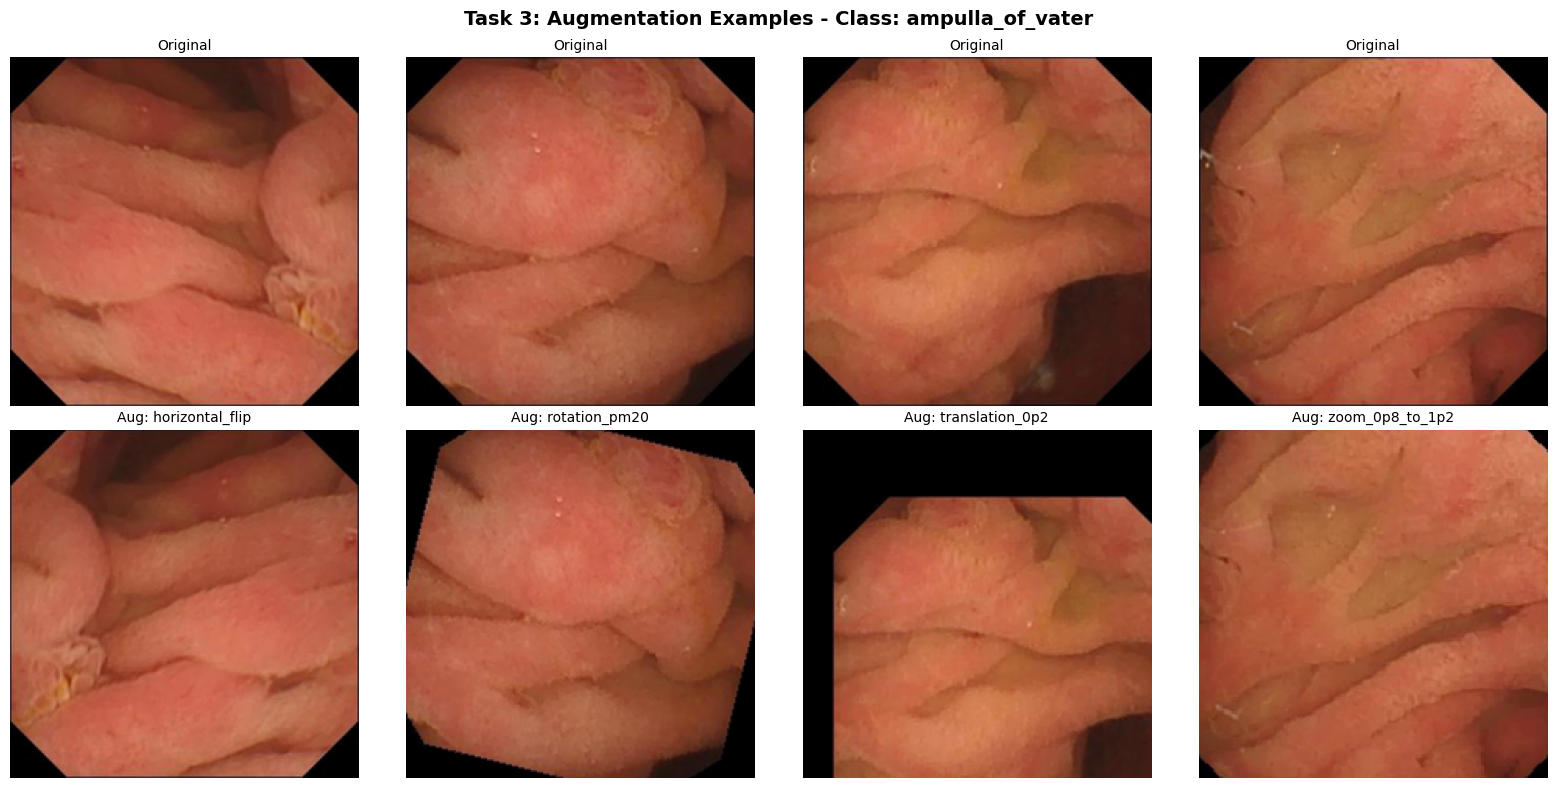

In [13]:
# ============================================================
# Task 3.2: Show before/after augmentation sample images
#   - Uses Task 3.1 single-technique operators (no chaining)
# ============================================================

# Pick a minority class to show augmentation examples
minority_example = sorted(minority_classes.items(), key=lambda x: x[1])[0][0]
example_class_dir = os.path.join(UNDERSAMPLED_DIR, minority_example)
example_images = [
    f for f in os.listdir(example_class_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
]

if example_images:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(
        f'Task 3: Augmentation Examples - Class: {minority_example}',
        fontsize=14,
        fontweight='bold'
    )

    # Select up to 4 techniques from Task 3.1 for visualization
    vis_techniques = list(AUG_TECHNIQUES.keys())[:4]

    # Top row: original images
    for i in range(4):
        img_path = os.path.join(example_class_dir, example_images[i % len(example_images)])
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        axes[0][i].imshow(img)
        axes[0][i].set_title('Original', fontsize=10)
        axes[0][i].axis('off')

    # Bottom row: one single-technique augmentation per column
    for i in range(4):
        tech_name = vis_techniques[i % len(vis_techniques)]
        img_path = os.path.join(example_class_dir, example_images[i % len(example_images)])
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        aug_img = _apply_single_augmentation(img, tech_name)
        axes[1][i].imshow(aug_img)
        axes[1][i].set_title(f'Aug: {tech_name}', fontsize=10)
        axes[1][i].axis('off')

    plt.tight_layout()
    plt.savefig('task3_augmentation_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'No images found in class folder: {example_class_dir}')

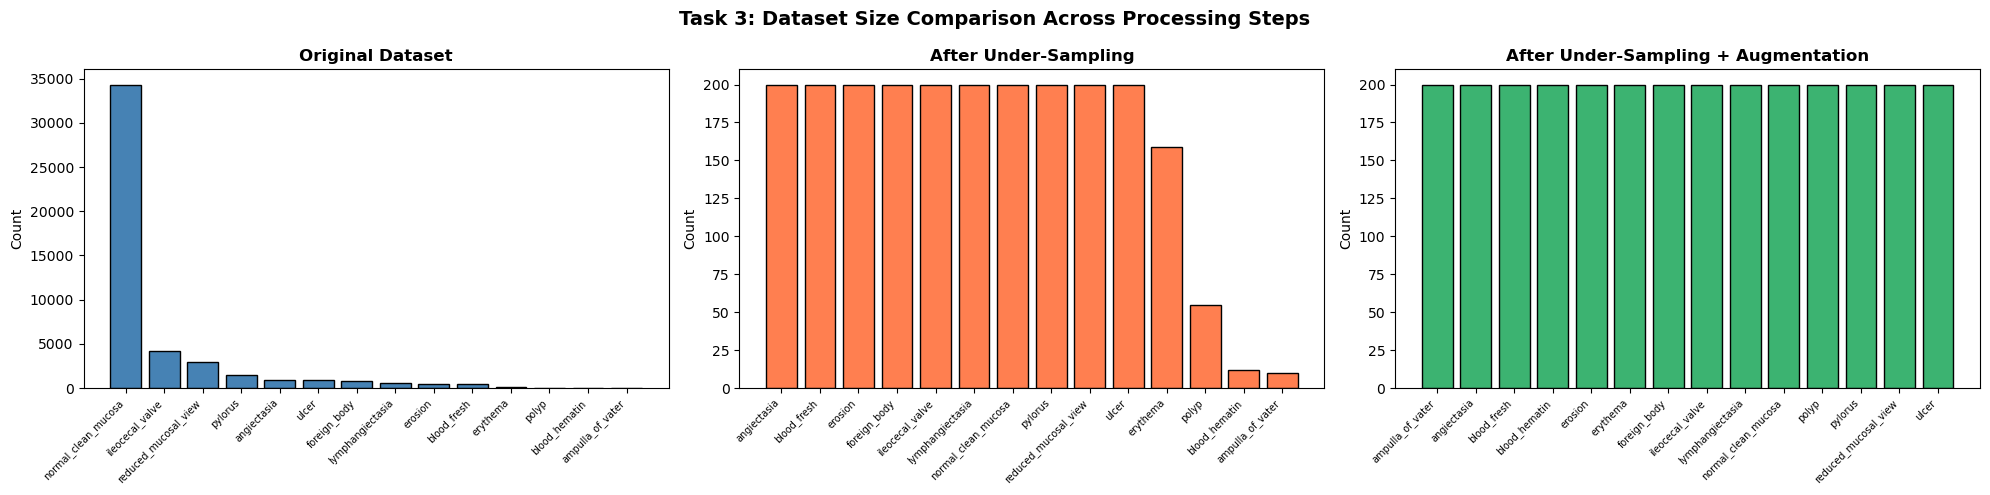

Original total: 47238
After under-sampling: 2236
After under-sampling + augmentation: 2800


In [14]:
# ============================================================
# Task 3.3: Updated dataset size summary
# ============================================================

augmented_dist = get_class_distribution(AUGMENTED_DIR)
aug_sorted = sorted(augmented_dist.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Original
axes[0].bar(range(len(sorted_names)), sorted_counts, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(sorted_names)))
axes[0].set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=7)
axes[0].set_title('Original Dataset', fontweight='bold')
axes[0].set_ylabel('Count')

# After under-sampling
us_d = get_class_distribution(UNDERSAMPLED_DIR)
us_s = sorted(us_d.items(), key=lambda x: x[1], reverse=True)
axes[1].bar(range(len(us_s)), [x[1] for x in us_s], color='coral', edgecolor='black')
axes[1].set_xticks(range(len(us_s)))
axes[1].set_xticklabels([x[0] for x in us_s], rotation=45, ha='right', fontsize=7)
axes[1].set_title('After Under-Sampling', fontweight='bold')
axes[1].set_ylabel('Count')

# After under-sampling + augmentation
axes[2].bar(range(len(aug_sorted)), [x[1] for x in aug_sorted], color='mediumseagreen', edgecolor='black')
axes[2].set_xticks(range(len(aug_sorted)))
axes[2].set_xticklabels([x[0] for x in aug_sorted], rotation=45, ha='right', fontsize=7)
axes[2].set_title('After Under-Sampling + Augmentation', fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Task 3: Dataset Size Comparison Across Processing Steps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Original total: {sum(class_counts)}')
print(f'After under-sampling: {sum(us_d.values())}')
print(f'After under-sampling + augmentation: {sum(augmented_dist.values())}')

---
# Task 4: Data Pre-Processing

In [ ]:
# ============================================================
# Task 4: Custom Dataset class and data preparation utilities
# ============================================================

class WCEDataset(Dataset):
    """Custom PyTorch Dataset for WCE image classification."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


def _source_image_key(file_name):
    """Map augmented files to their original source file for split grouping."""
    if file_name.startswith('aug_'):
        parts = file_name.split('_', 2)
        if len(parts) == 3 and parts[2]:
            return parts[2]
    return file_name


def collect_samples_with_group_ids(dataset_dir, class_to_idx):
    """Collect image paths, labels, and group IDs to avoid augmentation leakage."""
    samples = []  # (img_path, label, group_id)
    for class_name in sorted(os.listdir(dataset_dir)):
        class_path = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_path) or class_name not in class_to_idx:
            continue
        label = class_to_idx[class_name]
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                img_path = os.path.join(class_path, img_name)
                group_key = _source_image_key(img_name)
                group_id = f'{class_name}::{group_key}'
                samples.append((img_path, label, group_id))
    return samples


# Standard transforms: resize to 224x224, normalize to [0,1] then ImageNet stats
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),                         
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [16]:
# ============================================================
# Task 4: Prepare three dataset variants for the three
#         training settings (original, undersampled, augmented)
# ============================================================

# Build class-to-index mapping from the original dataset
class_to_idx = {name: idx for idx, name in enumerate(sorted(class_distribution.keys()))}
idx_to_class = {v: k for k, v in class_to_idx.items()}
print('Class mapping:', class_to_idx)

def prepare_dataloaders(dataset_dir, class_to_idx, train_tf, val_tf, batch_size):
    """Create leakage-safe train/val/test DataLoaders with 70/15/15 split."""
    samples = collect_samples_with_group_ids(dataset_dir, class_to_idx)

    # Group by source image key so augmented variants stay in the same split.
    group_to_items = defaultdict(list)
    group_to_label = {}
    for img_path, label, group_id in samples:
        group_to_items[group_id].append((img_path, label))
        group_to_label[group_id] = label

    group_ids = list(group_to_items.keys())
    group_labels = [group_to_label[g] for g in group_ids]

    # Split groups: 70% train, 15% val, 15% test
    train_groups, temp_groups, _, temp_group_labels = train_test_split(
        group_ids, group_labels, test_size=0.30, random_state=SEED, stratify=group_labels
    )
    val_groups, test_groups, _, _ = train_test_split(
        temp_groups, temp_group_labels, test_size=0.50, random_state=SEED, stratify=temp_group_labels
    )

    def _expand_groups(selected_groups):
        paths, labels = [], []
        for gid in selected_groups:
            for p, y in group_to_items[gid]:
                paths.append(p)
                labels.append(y)
        return paths, labels

    train_paths, train_labels = _expand_groups(train_groups)
    val_paths, val_labels = _expand_groups(val_groups)
    test_paths, test_labels = _expand_groups(test_groups)

    train_ds = WCEDataset(train_paths, train_labels, transform=train_tf)
    val_ds = WCEDataset(val_paths, val_labels, transform=val_tf)
    test_ds = WCEDataset(test_paths, test_labels, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    print(f'  Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
    return train_loader, val_loader, test_loader


# Setting 1: Original (no imbalance handling)
print('Setting 1 - Original dataset:')
orig_train, orig_val, orig_test = prepare_dataloaders(
    DATASET_DIR, class_to_idx, train_transform, val_test_transform, BATCH_SIZE
)

# Setting 2: Under-sampled only
print('\nSetting 2 - Under-sampled dataset:')
us_train, us_val, us_test = prepare_dataloaders(
    UNDERSAMPLED_DIR, class_to_idx, train_transform, val_test_transform, BATCH_SIZE
)

# Setting 3: Under-sampled + Augmented
print('\nSetting 3 - Under-sampled + Augmented dataset:')
aug_train, aug_val, aug_test = prepare_dataloaders(
    AUGMENTED_DIR, class_to_idx, train_transform, val_test_transform, BATCH_SIZE
)

# Store all settings for iteration during training
data_settings = {
    'Original (No Handling)': (orig_train, orig_val, orig_test),
    'Under-Sampled Only': (us_train, us_val, us_test),
    'Under-Sampled + Augmented': (aug_train, aug_val, aug_test),
}

Class mapping: {'ampulla_of_vater': 0, 'angiectasia': 1, 'blood_fresh': 2, 'blood_hematin': 3, 'erosion': 4, 'erythema': 5, 'foreign_body': 6, 'ileocecal_valve': 7, 'lymphangiectasia': 8, 'normal_clean_mucosa': 9, 'polyp': 10, 'pylorus': 11, 'reduced_mucosal_view': 12, 'ulcer': 13}
Setting 1 - Original dataset:
  Train: 33066 | Val: 7086 | Test: 7086

Setting 2 - Under-sampled dataset:
  Train: 1565 | Val: 335 | Test: 336

Setting 3 - Under-sampled + Augmented dataset:
  Train: 1960 | Val: 420 | Test: 420


---
# Task 5: Model Design Using Transfer Learning

In [17]:
# ============================================================
# Task 5: Model builder with transfer learning
#   - Load pretrained model (ImageNet weights)
#   - Freeze early layers (~80%)
#   - Replace classifier with dropout + L2-ready head
# ============================================================

def build_efficientnet_b0(num_classes, freeze_ratio=0.8):
    """EfficientNet-B0 with frozen early layers and custom classifier."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze early layers
    params = list(model.features.parameters())
    freeze_count = int(len(params) * freeze_ratio)
    for param in params[:freeze_count]:
        param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


def build_mobilenet_v3_small(num_classes, freeze_ratio=0.8):
    """MobileNetV3-Small with frozen early layers and custom classifier."""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

    # Freeze early layers
    params = list(model.features.parameters())
    freeze_count = int(len(params) * freeze_ratio)
    for param in params[:freeze_count]:
        param.requires_grad = False

    # MobileNetV3-Small classifier receives 576-dim pooled features.
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


def build_inception_v3(num_classes, freeze_ratio=0.8):
    """InceptionV3 with frozen early layers and custom classifier."""
    # With pretrained weights in torchvision, aux_logits is initialized as True.
    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
    model.aux_logits = False
    model.AuxLogits = None

    # Freeze early layers
    all_params = list(model.parameters())
    freeze_count = int(len(all_params) * freeze_ratio)
    for param in all_params[:freeze_count]:
        param.requires_grad = False

    # Replace FC head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


# Model registry
MODEL_BUILDERS = {
    'EfficientNet-B0': build_efficientnet_b0,
    'MobileNetV3-Small': build_mobilenet_v3_small,
    'InceptionV3': build_inception_v3,
}

In [18]:
# ============================================================
# Task 5: Display model summaries - trainable vs frozen params
# ============================================================

print('=' * 70)
print('MODEL SUMMARIES - Trainable vs Frozen Parameters')
print('=' * 70)

summary_data = []

for model_name, builder in MODEL_BUILDERS.items():
    model = builder(num_classes)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    summary_data.append({
        'Model': model_name,
        'Total Params': f'{total_params:,}',
        'Trainable': f'{trainable_params:,}',
        'Frozen': f'{frozen_params:,}',
        'Trainable %': f'{trainable_params / total_params * 100:.1f}%'
    })

    print(f'\n{model_name}:')
    print(f'  Total parameters:     {total_params:>12,}')
    print(f'  Trainable parameters: {trainable_params:>12,}')
    print(f'  Frozen parameters:    {frozen_params:>12,}')
    print(f'  Trainable ratio:      {trainable_params / total_params * 100:.1f}%')

    del model

print('\n' + '=' * 70)
summary_df = pd.DataFrame(summary_data)
print('\nComparative Summary:')
print(summary_df.to_string(index=False))

MODEL SUMMARIES - Trainable vs Frozen Parameters

EfficientNet-B0:
  Total parameters:        4,339,082
  Trainable parameters:    2,637,022
  Frozen parameters:       1,702,060
  Trainable ratio:      60.8%

MobileNetV3-Small:
  Total parameters:        1,078,318
  Trainable parameters:      740,654
  Frozen parameters:         337,664
  Trainable ratio:      68.7%

InceptionV3:
  Total parameters:       22,313,710
  Trainable parameters:   11,649,742
  Frozen parameters:      10,663,968
  Trainable ratio:      52.2%


Comparative Summary:
            Model Total Params  Trainable     Frozen Trainable %
  EfficientNet-B0    4,339,082  2,637,022  1,702,060       60.8%
MobileNetV3-Small    1,078,318    740,654    337,664       68.7%
      InceptionV3   22,313,710 11,649,742 10,663,968       52.2%


---
# Task 6: Intelligent Learning Rate Control



We use a smart learning-rate rule so training is both fast and stable:

1. Start with a normal learning rate (`1e-3`).
2. Use a cosine pattern to gradually lower and restart the LR over epochs.
3. Watch validation loss each epoch.
4. If validation loss stops improving, reduce LR further (plateau scaling).
5. Keep LR within safe bounds (`1e-6` to `1e-3`).

Why this helps:
- Early epochs learn quickly.
- Later epochs fine-tune with smaller LR.
- Different model/dataset runs can get different LR curves based on validation behavior.

In [19]:
# ============================================================
# Task 6: Learning rate scheduling strategy
#   - Adaptive Cosine schedule with warm restarts
#   - Plateau-driven multiplicative scaling
#   - L2 regularization via weight_decay in optimizer
# ============================================================

INITIAL_LR = 1e-3
WEIGHT_DECAY = 1e-4   # L2 regularization


class AdaptiveCosinePlateauController:
    """Hybrid LR controller: cosine warm-restarts + plateau scaling."""

    def __init__(
        self,
        optimizer,
        initial_lr=1e-3,
        eta_min=1e-6,
        t0=2,
        t_mult=2,
        plateau_factor=0.5,
        plateau_patience=1,
        min_lr=1e-6,
        improvement_eps=1e-6,
    ):
        self.optimizer = optimizer
        self.initial_lr = initial_lr
        self.eta_min = eta_min
        self.t0 = t0
        self.t_mult = t_mult
        self.plateau_factor = plateau_factor
        self.plateau_patience = plateau_patience
        self.min_lr = min_lr
        self.improvement_eps = improvement_eps

        self.best_val_loss = float('inf')
        self.bad_epochs = 0
        self.plateau_scale = 1.0

        self.cycle_len = t0
        self.cycle_pos = 0

    def _cosine_lr(self):
        # Cosine interpolation over current cycle position.
        cosine = 0.5 * (1 + np.cos(np.pi * (self.cycle_pos / max(self.cycle_len, 1))))
        return self.eta_min + (self.initial_lr - self.eta_min) * cosine

    def _set_lr(self, lr):
        for g in self.optimizer.param_groups:
            g['lr'] = lr

    def current_lr(self):
        return self.optimizer.param_groups[0]['lr']

    def step(self, val_loss):
        # Plateau tracking based on validation loss.
        if val_loss < self.best_val_loss - self.improvement_eps:
            self.best_val_loss = val_loss
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
            if self.bad_epochs > self.plateau_patience:
                self.plateau_scale *= self.plateau_factor
                self.bad_epochs = 0

        # Hybrid LR = cosine component scaled by plateau component.
        next_lr = self._cosine_lr() * self.plateau_scale
        next_lr = float(np.clip(next_lr, self.min_lr, self.initial_lr))
        self._set_lr(next_lr)

        # Advance cosine cycle state.
        self.cycle_pos += 1
        if self.cycle_pos >= self.cycle_len:
            self.cycle_pos = 0
            self.cycle_len *= self.t_mult

        return next_lr


def create_optimizer_and_schedulers(model):
    """Create Adam optimizer + adaptive hybrid LR controller."""
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=INITIAL_LR,
        weight_decay=WEIGHT_DECAY,
    )

    lr_controller = AdaptiveCosinePlateauController(
        optimizer,
        initial_lr=INITIAL_LR,
        eta_min=1e-6,
        t0=2,
        t_mult=2,
        plateau_factor=0.5,
        plateau_patience=1,
        min_lr=1e-6,
    )

    # Ensure optimizer starts with the configured initial LR.
    for g in optimizer.param_groups:
        g['lr'] = INITIAL_LR

    return optimizer, lr_controller

---
# Task 7: Model Training and Evaluation

In [20]:
# ============================================================
# Task 7: Training and evaluation functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device, epoch_idx, num_epochs, run_label):
    """Train for one epoch with batch-level progress bar."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(
        loader,
        desc=f'Train | {run_label} | Epoch {epoch_idx + 1}/{num_epochs}',
        leave=False,
        dynamic_ncols=True,
        mininterval=0.3,
        ascii=True
    )

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / max(total, 1)
        avg_acc = correct / max(total, 1)
        current_lr = optimizer.param_groups[0]['lr']
        train_bar.set_postfix(loss=f'{avg_loss:.4f}', acc=f'{avg_acc:.4f}', lr=f'{current_lr:.2e}')

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch_idx=None, num_epochs=None, run_label=None, split='Val', show_progress=False):
    """Evaluate model. Returns loss, accuracy, predictions, and true labels."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    if show_progress and epoch_idx is not None and num_epochs is not None and run_label is not None:
        data_iter = tqdm(
            loader,
            desc=f'{split} | {run_label} | Epoch {epoch_idx + 1}/{num_epochs}',
            leave=False,
            dynamic_ncols=True,
            mininterval=0.3,
            ascii=True
        )
    else:
        data_iter = loader

    for images, labels in data_iter:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if show_progress and hasattr(data_iter, 'set_postfix'):
            avg_loss = running_loss / max(total, 1)
            avg_acc = correct / max(total, 1)
            data_iter.set_postfix(loss=f'{avg_loss:.4f}', acc=f'{avg_acc:.4f}')

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model_name, setting_name, builder, train_loader, val_loader, test_loader,
                num_classes, num_epochs, device):
    """Full training pipeline for one model + one data setting."""
    model = builder(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer, lr_controller = create_optimizer_and_schedulers(model)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_state = None
    run_label = f'{model_name} | {setting_name}'

    for epoch in range(num_epochs):
        print(f'  Starting epoch {epoch + 1}/{num_epochs}...')
        lr_at_epoch_start = optimizer.param_groups[0]['lr']

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch, num_epochs, run_label
        )
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device,
            epoch_idx=epoch, num_epochs=num_epochs, run_label=run_label, split='Val', show_progress=True
        )
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Step adaptive LR controller using validation loss and log effective LR.
        lr_after_update = lr_controller.step(val_loss)
        history['lr'].append(lr_after_update)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        print(f'  Epoch {epoch+1:2d}/{num_epochs} | '
              f'LR(start): {lr_at_epoch_start:.6f} | '
              f'LR(next): {lr_after_update:.6f} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    # Load best model and evaluate on test set
    model.load_state_dict(best_model_state)
    _, _, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device, split='Test', show_progress=False
    )

    # Compute metrics
    metrics = {
        'accuracy': accuracy_score(test_labels, test_preds),
        'precision': precision_score(test_labels, test_preds, average='weighted', zero_division=0),
        'recall': recall_score(test_labels, test_preds, average='weighted', zero_division=0),
        'f1': f1_score(test_labels, test_preds, average='weighted', zero_division=0),
    }

    print(f'\n  Test Results: Acc={metrics["accuracy"]:.4f} | '
          f'P={metrics["precision"]:.4f} | R={metrics["recall"]:.4f} | F1={metrics["f1"]:.4f}')

    return model, history, metrics, test_preds, test_labels

In [21]:
# ============================================================
# Task 7: Train all models across all three data settings
#   - Supports resume: skip runs that are already persisted
# ============================================================

all_results = {}  # Stores lightweight run outputs for plotting/reporting
metrics_rows = []

live_metrics_path = os.path.join(RESULTS_DIR, 'task7_metrics_live.csv')
existing_metrics_df = pd.read_csv(live_metrics_path) if os.path.exists(live_metrics_path) else pd.DataFrame()

def _safe_name(text):
    return text.lower().replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')

for setting_name, (train_loader, val_loader, test_loader) in data_settings.items():
    for model_name, builder in MODEL_BUILDERS.items():
        key = (model_name, setting_name)
        safe_model = _safe_name(model_name)
        safe_setting = _safe_name(setting_name)

        history_path = os.path.join(RESULTS_DIR, f'history_{safe_model}__{safe_setting}.csv')
        preds_path = os.path.join(RESULTS_DIR, f'preds_{safe_model}__{safe_setting}.npz')

        run_exists = os.path.exists(history_path) and os.path.exists(preds_path)
        if run_exists:
            print('\n' + '=' * 70)
            print(f'Skipping {model_name} on [{setting_name}] (already saved)')
            print('=' * 70)

            history_df = pd.read_csv(history_path)
            pred_pack = np.load(preds_path)
            preds = pred_pack['preds']
            labels = pred_pack['labels']

            history = {
                'train_loss': history_df['train_loss'].tolist(),
                'train_acc': history_df['train_acc'].tolist(),
                'val_loss': history_df['val_loss'].tolist(),
                'val_acc': history_df['val_acc'].tolist(),
                'lr': history_df['lr'].tolist(),
            }

            row = pd.DataFrame()
            if not existing_metrics_df.empty:
                row = existing_metrics_df[
                    (existing_metrics_df['Model'] == model_name) &
                    (existing_metrics_df['Setting'] == setting_name)
                ]

            if not row.empty:
                metrics = {
                    'accuracy': float(row.iloc[0]['Accuracy']),
                    'precision': float(row.iloc[0]['Precision']),
                    'recall': float(row.iloc[0]['Recall']),
                    'f1': float(row.iloc[0]['F1-Score']),
                }
            else:
                metrics = {
                    'accuracy': accuracy_score(labels, preds),
                    'precision': precision_score(labels, preds, average='weighted', zero_division=0),
                    'recall': recall_score(labels, preds, average='weighted', zero_division=0),
                    'f1': f1_score(labels, preds, average='weighted', zero_division=0),
                }

            all_results[key] = {
                'history': history,
                'metrics': metrics,
                'preds': preds,
                'labels': labels,
            }

            metrics_rows.append({
                'Model': model_name,
                'Setting': setting_name,
                'Accuracy': metrics['accuracy'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1-Score': metrics['f1'],
            })
            continue

        print('\n' + '=' * 70)
        print(f'Training {model_name} on [{setting_name}]')
        print('=' * 70)

        model, history, metrics, preds, labels = train_model(
            model_name, setting_name, builder, train_loader, val_loader, test_loader,
            num_classes, NUM_EPOCHS, DEVICE
        )

        # Keep only compact results needed later for plots/reports.
        all_results[key] = {
            'history': history,
            'metrics': metrics,
            'preds': preds,
            'labels': labels,
        }

        metrics_rows.append({
            'Model': model_name,
            'Setting': setting_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1'],
        })

        # Persist per-run history and predictions for reuse without retraining.
        history_df = pd.DataFrame({
            'epoch': np.arange(1, len(history['train_loss']) + 1),
            'train_loss': history['train_loss'],
            'train_acc': history['train_acc'],
            'val_loss': history['val_loss'],
            'val_acc': history['val_acc'],
            'lr': history['lr'],
        })
        history_df.to_csv(history_path, index=False)
        np.savez_compressed(preds_path, preds=preds, labels=labels)

        # Save running metrics table after each run.
        pd.DataFrame(metrics_rows).to_csv(live_metrics_path, index=False)

        # Free GPU memory from this model before next training run.
        model.to('cpu')
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

comparison_df = pd.DataFrame(metrics_rows)
comparison_df.to_csv(os.path.join(RESULTS_DIR, 'task7_comparison.csv'), index=False)

print(f'\n\nAll training complete! Results saved in: {os.path.abspath(RESULTS_DIR)}')


Training EfficientNet-B0 on [Original (No Handling)]
  Starting epoch 1/5...


Train | EfficientNet-B0 | Original (No Handling) | Epoch 1/5:   0%|          | 0/2067 [00:00<?, ?it/s]

Val | EfficientNet-B0 | Original (No Handling) | Epoch 1/5:   0%|          | 0/443 [00:00<?, ?it/s]

  Epoch  1/5 | LR(start): 0.001000 | LR(next): 0.001000 | Train Loss: 0.3818 Acc: 0.8866 | Val Loss: 0.1482 Acc: 0.9558
  Starting epoch 2/5...


Train | EfficientNet-B0 | Original (No Handling) | Epoch 2/5:   0%|          | 0/2067 [00:00<?, ?it/s]

...

Val | InceptionV3 | Under-Sampled + Augmented | Epoch 4/5:   0%|          | 0/27 [00:00<?, ?it/s]

  Epoch  4/5 | LR(start): 0.001000 | LR(next): 0.000854 | Train Loss: 0.7095 Acc: 0.7704 | Val Loss: 0.8636 Acc: 0.7262
  Starting epoch 5/5...


Train | InceptionV3 | Under-Sampled + Augmented | Epoch 5/5:   0%|          | 0/123 [00:00<?, ?it/s]

Val | InceptionV3 | Under-Sampled + Augmented | Epoch 5/5:   0%|          | 0/27 [00:00<?, ?it/s]

  Epoch  5/5 | LR(start): 0.000854 | LR(next): 0.000250 | Train Loss: 0.5769 Acc: 0.8184 | Val Loss: 0.7939 Acc: 0.7810

  Test Results: Acc=0.7857 | P=0.7827 | R=0.7857 | F1=0.7810


All training complete! Results saved in: c:\Users\tarun\OneDrive\Desktop\Project-DL\results


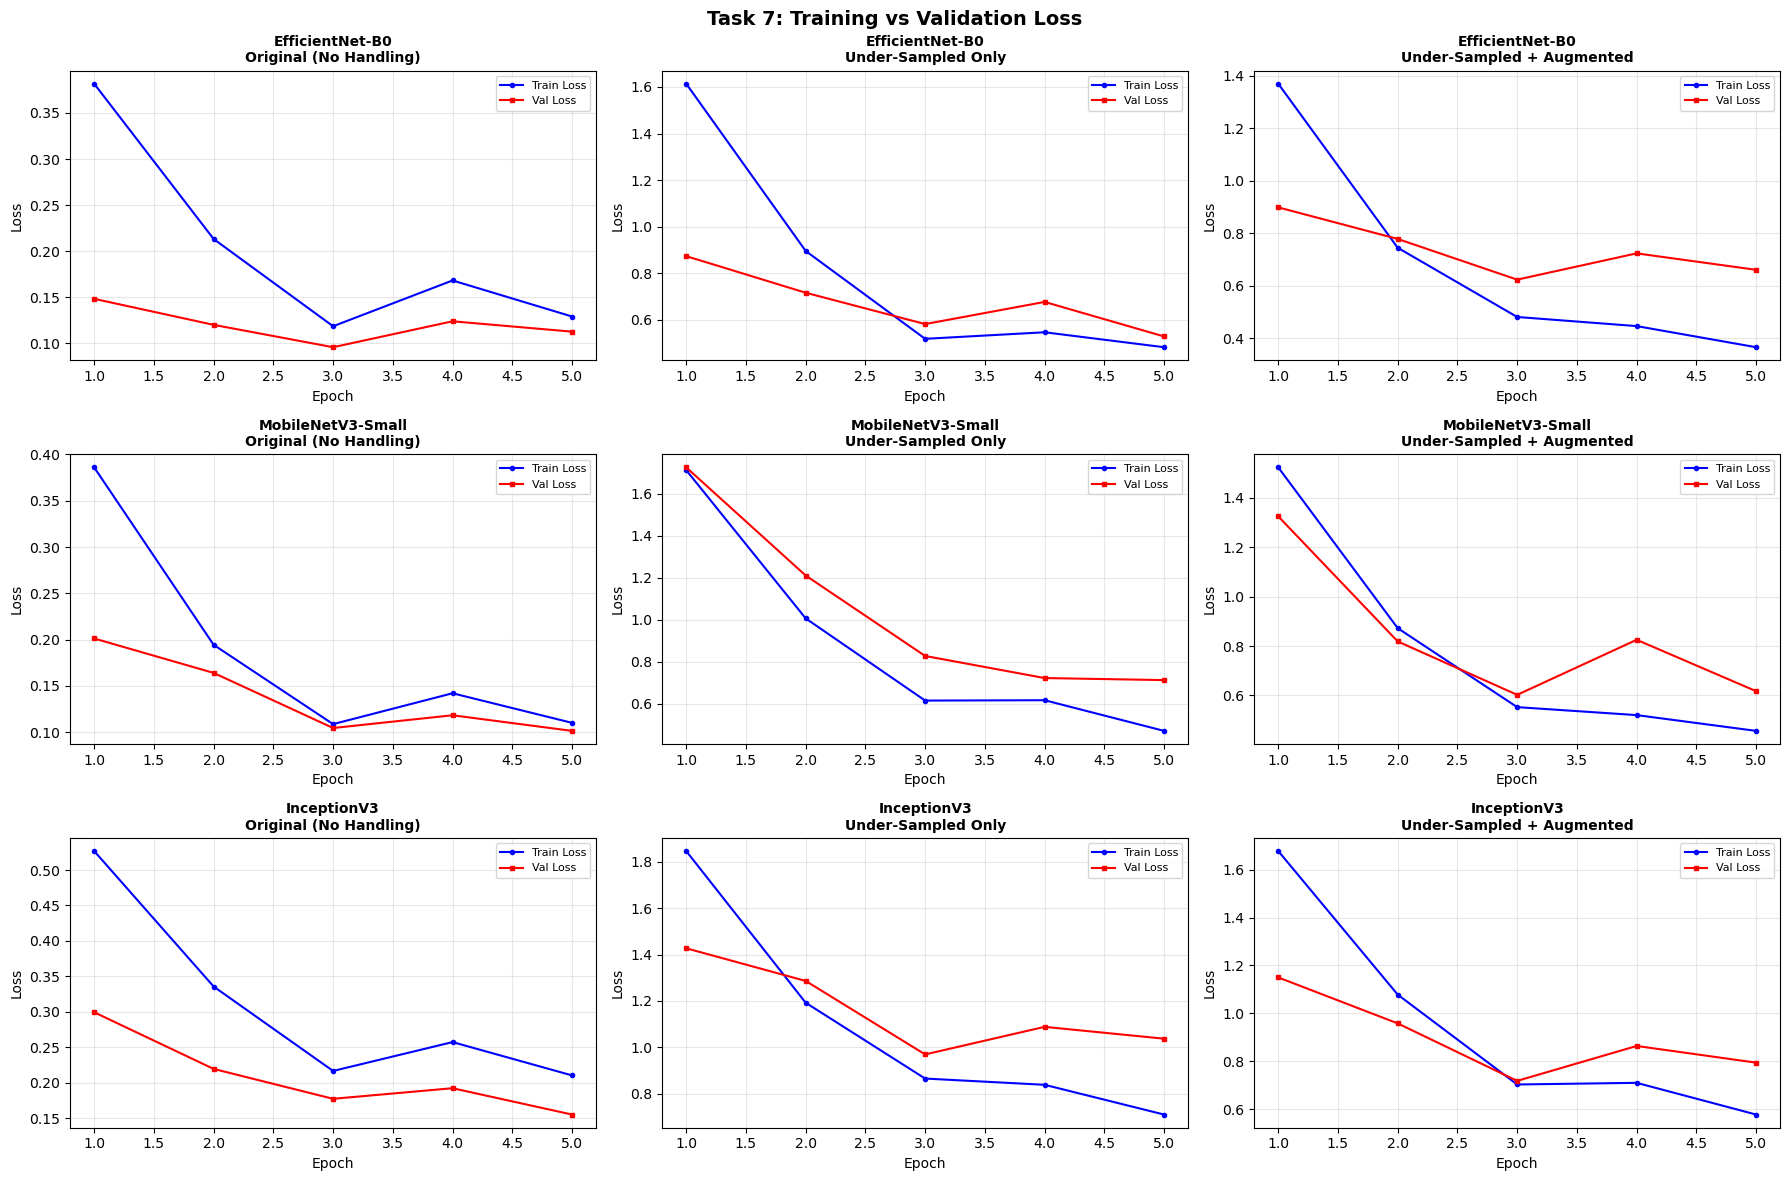

In [22]:
# ============================================================
# Task 7: Training vs Validation Loss Curves
# ============================================================

model_names_list = list(MODEL_BUILDERS.keys())
setting_names_list = list(data_settings.keys())

fig, axes = plt.subplots(len(model_names_list), len(setting_names_list),
                         figsize=(6 * len(setting_names_list), 4 * len(model_names_list)))

for i, model_name in enumerate(model_names_list):
    for j, setting_name in enumerate(setting_names_list):
        ax = axes[i][j] if len(model_names_list) > 1 else axes[j]
        h = all_results[(model_name, setting_name)]['history']
        epochs = range(1, len(h['train_loss']) + 1)

        ax.plot(epochs, h['train_loss'], 'b-o', markersize=3, label='Train Loss')
        ax.plot(epochs, h['val_loss'], 'r-s', markersize=3, label='Val Loss')
        ax.set_title(f'{model_name}\n{setting_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Task 7: Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

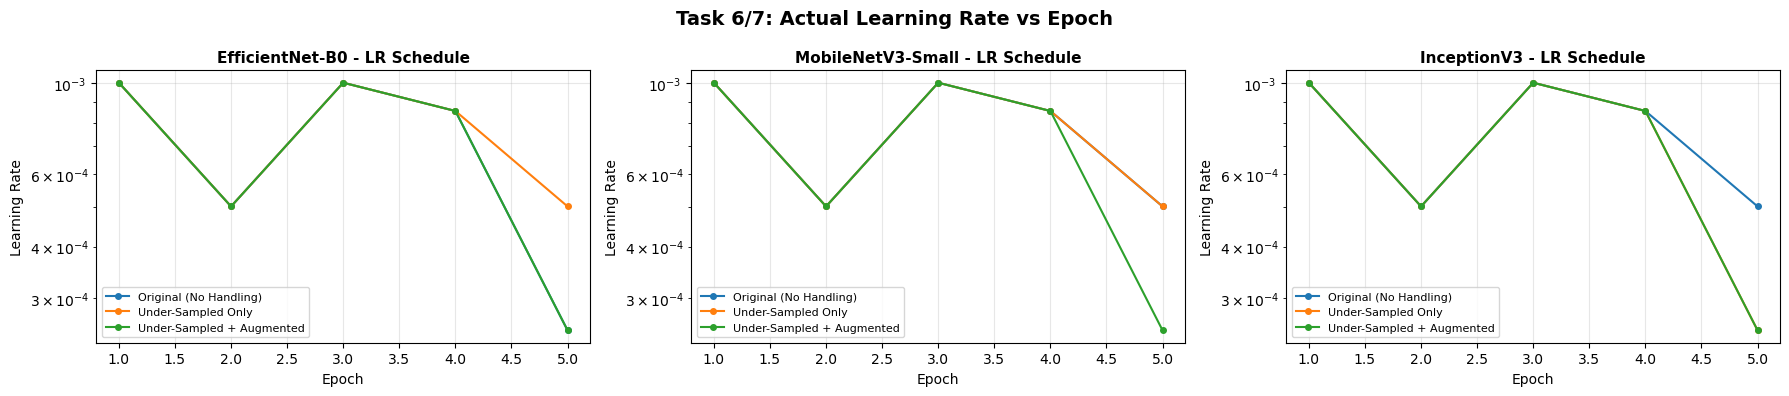

In [23]:
# ============================================================
# Task 7: Learning Rate vs Epoch (actual LR during training)
# ============================================================

fig, axes = plt.subplots(1, len(model_names_list), figsize=(6 * len(model_names_list), 4))
if len(model_names_list) == 1:
    axes = [axes]

for i, model_name in enumerate(model_names_list):
    for setting_name in setting_names_list:
        h = all_results[(model_name, setting_name)]['history']
        axes[i].plot(range(1, len(h['lr']) + 1), h['lr'], '-o', markersize=4, label=setting_name)

    axes[i].set_title(f'{model_name} - LR Schedule', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Learning Rate')
    axes[i].set_yscale('log')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Task 6/7: Actual Learning Rate vs Epoch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_lr_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## Learning Rate Scheduling Strategy (Task 6)

In this experiment, an adaptive learning rate strategy was used by combining **cosine annealing with warm restarts** and **plateau-based reduction**.

###  How the Learning Rate Changes

- At the beginning of training, the learning rate is set to a **high value (1e-3)** to allow the model to learn quickly.
- As training progresses, the learning rate **gradually decreases** following a cosine pattern, enabling finer adjustments to the model weights.
- Periodically, the learning rate is **increased again (warm restart)**. This helps the model escape local minima and explore better solutions.
- Additionally, when the **validation loss stops improving**, the learning rate is further **reduced automatically** using a plateau-based strategy.

###  Observations from the Graph

- The learning rate shows a **cyclic pattern** due to cosine annealing with warm restarts.
- A **drop in learning rate at later epochs** indicates activation of the plateau mechanism.
- Similar patterns across different models are expected since the same scheduling strategy is applied.

###  Benefits of This Approach

- **Fast initial learning** due to high learning rate
- **Better exploration** of solution space through restarts
- **Stable convergence** with gradual reduction in learning rate
- **Adaptive behavior** based on validation performance

Overall, this hybrid approach ensures efficient training by balancing exploration and fine-tuning, leading to improved model performance.

In [24]:
# ============================================================
# Task 7: Comparison Table
# ============================================================

comparison_csv_path = os.path.join(RESULTS_DIR, 'task7_comparison.csv')

# Prefer persisted results when available; fallback to in-memory reconstruction.
if os.path.exists(comparison_csv_path):
    comparison_df = pd.read_csv(comparison_csv_path)
else:
    comparison_rows = []
    for (model_name, setting_name), result in all_results.items():
        m = result['metrics']
        comparison_rows.append({
            'Model': model_name,
            'Setting': setting_name,
            'Accuracy': m['accuracy'],
            'Precision': m['precision'],
            'Recall': m['recall'],
            'F1-Score': m['f1'],
        })
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(comparison_csv_path, index=False)

display_df = comparison_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    if col in display_df.columns:
        display_df[col] = display_df[col].map(lambda x: f'{x:.4f}')

print('\n' + '=' * 90)
print('COMPARISON TABLE: All Models x All Settings')
print('=' * 90)
print(display_df.to_string(index=False))
print(f'\nSaved at: {os.path.abspath(comparison_csv_path)}')


COMPARISON TABLE: All Models x All Settings
            Model                   Setting Accuracy Precision Recall F1-Score
  EfficientNet-B0    Original (No Handling)   0.9745    0.9751 0.9745   0.9743
MobileNetV3-Small    Original (No Handling)   0.9735    0.9734 0.9735   0.9730
      InceptionV3    Original (No Handling)   0.9578    0.9571 0.9578   0.9567
  EfficientNet-B0        Under-Sampled Only   0.7768    0.7795 0.7768   0.7714
MobileNetV3-Small        Under-Sampled Only   0.7232    0.7438 0.7232   0.7159
      InceptionV3        Under-Sampled Only   0.7054    0.7214 0.7054   0.7023
  EfficientNet-B0 Under-Sampled + Augmented   0.8452    0.8508 0.8452   0.8452
MobileNetV3-Small Under-Sampled + Augmented   0.8262    0.8325 0.8262   0.8234
      InceptionV3 Under-Sampled + Augmented   0.7857    0.7827 0.7857   0.7810

Saved at: c:\Users\tarun\OneDrive\Desktop\Project-DL\results\task7_comparison.csv


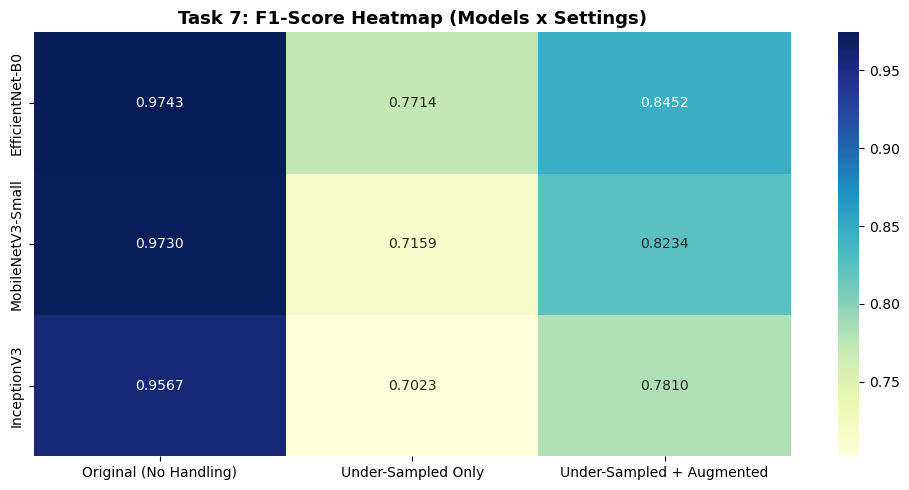

In [25]:
# ============================================================
# Task 7: Heatmap of F1-Scores
# ============================================================

f1_matrix = np.zeros((len(model_names_list), len(setting_names_list)))
for i, mn in enumerate(model_names_list):
    for j, sn in enumerate(setting_names_list):
        f1_matrix[i, j] = all_results[(mn, sn)]['metrics']['f1']

plt.figure(figsize=(10, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=setting_names_list, yticklabels=model_names_list)
plt.title('Task 7: F1-Score Heatmap (Models x Settings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

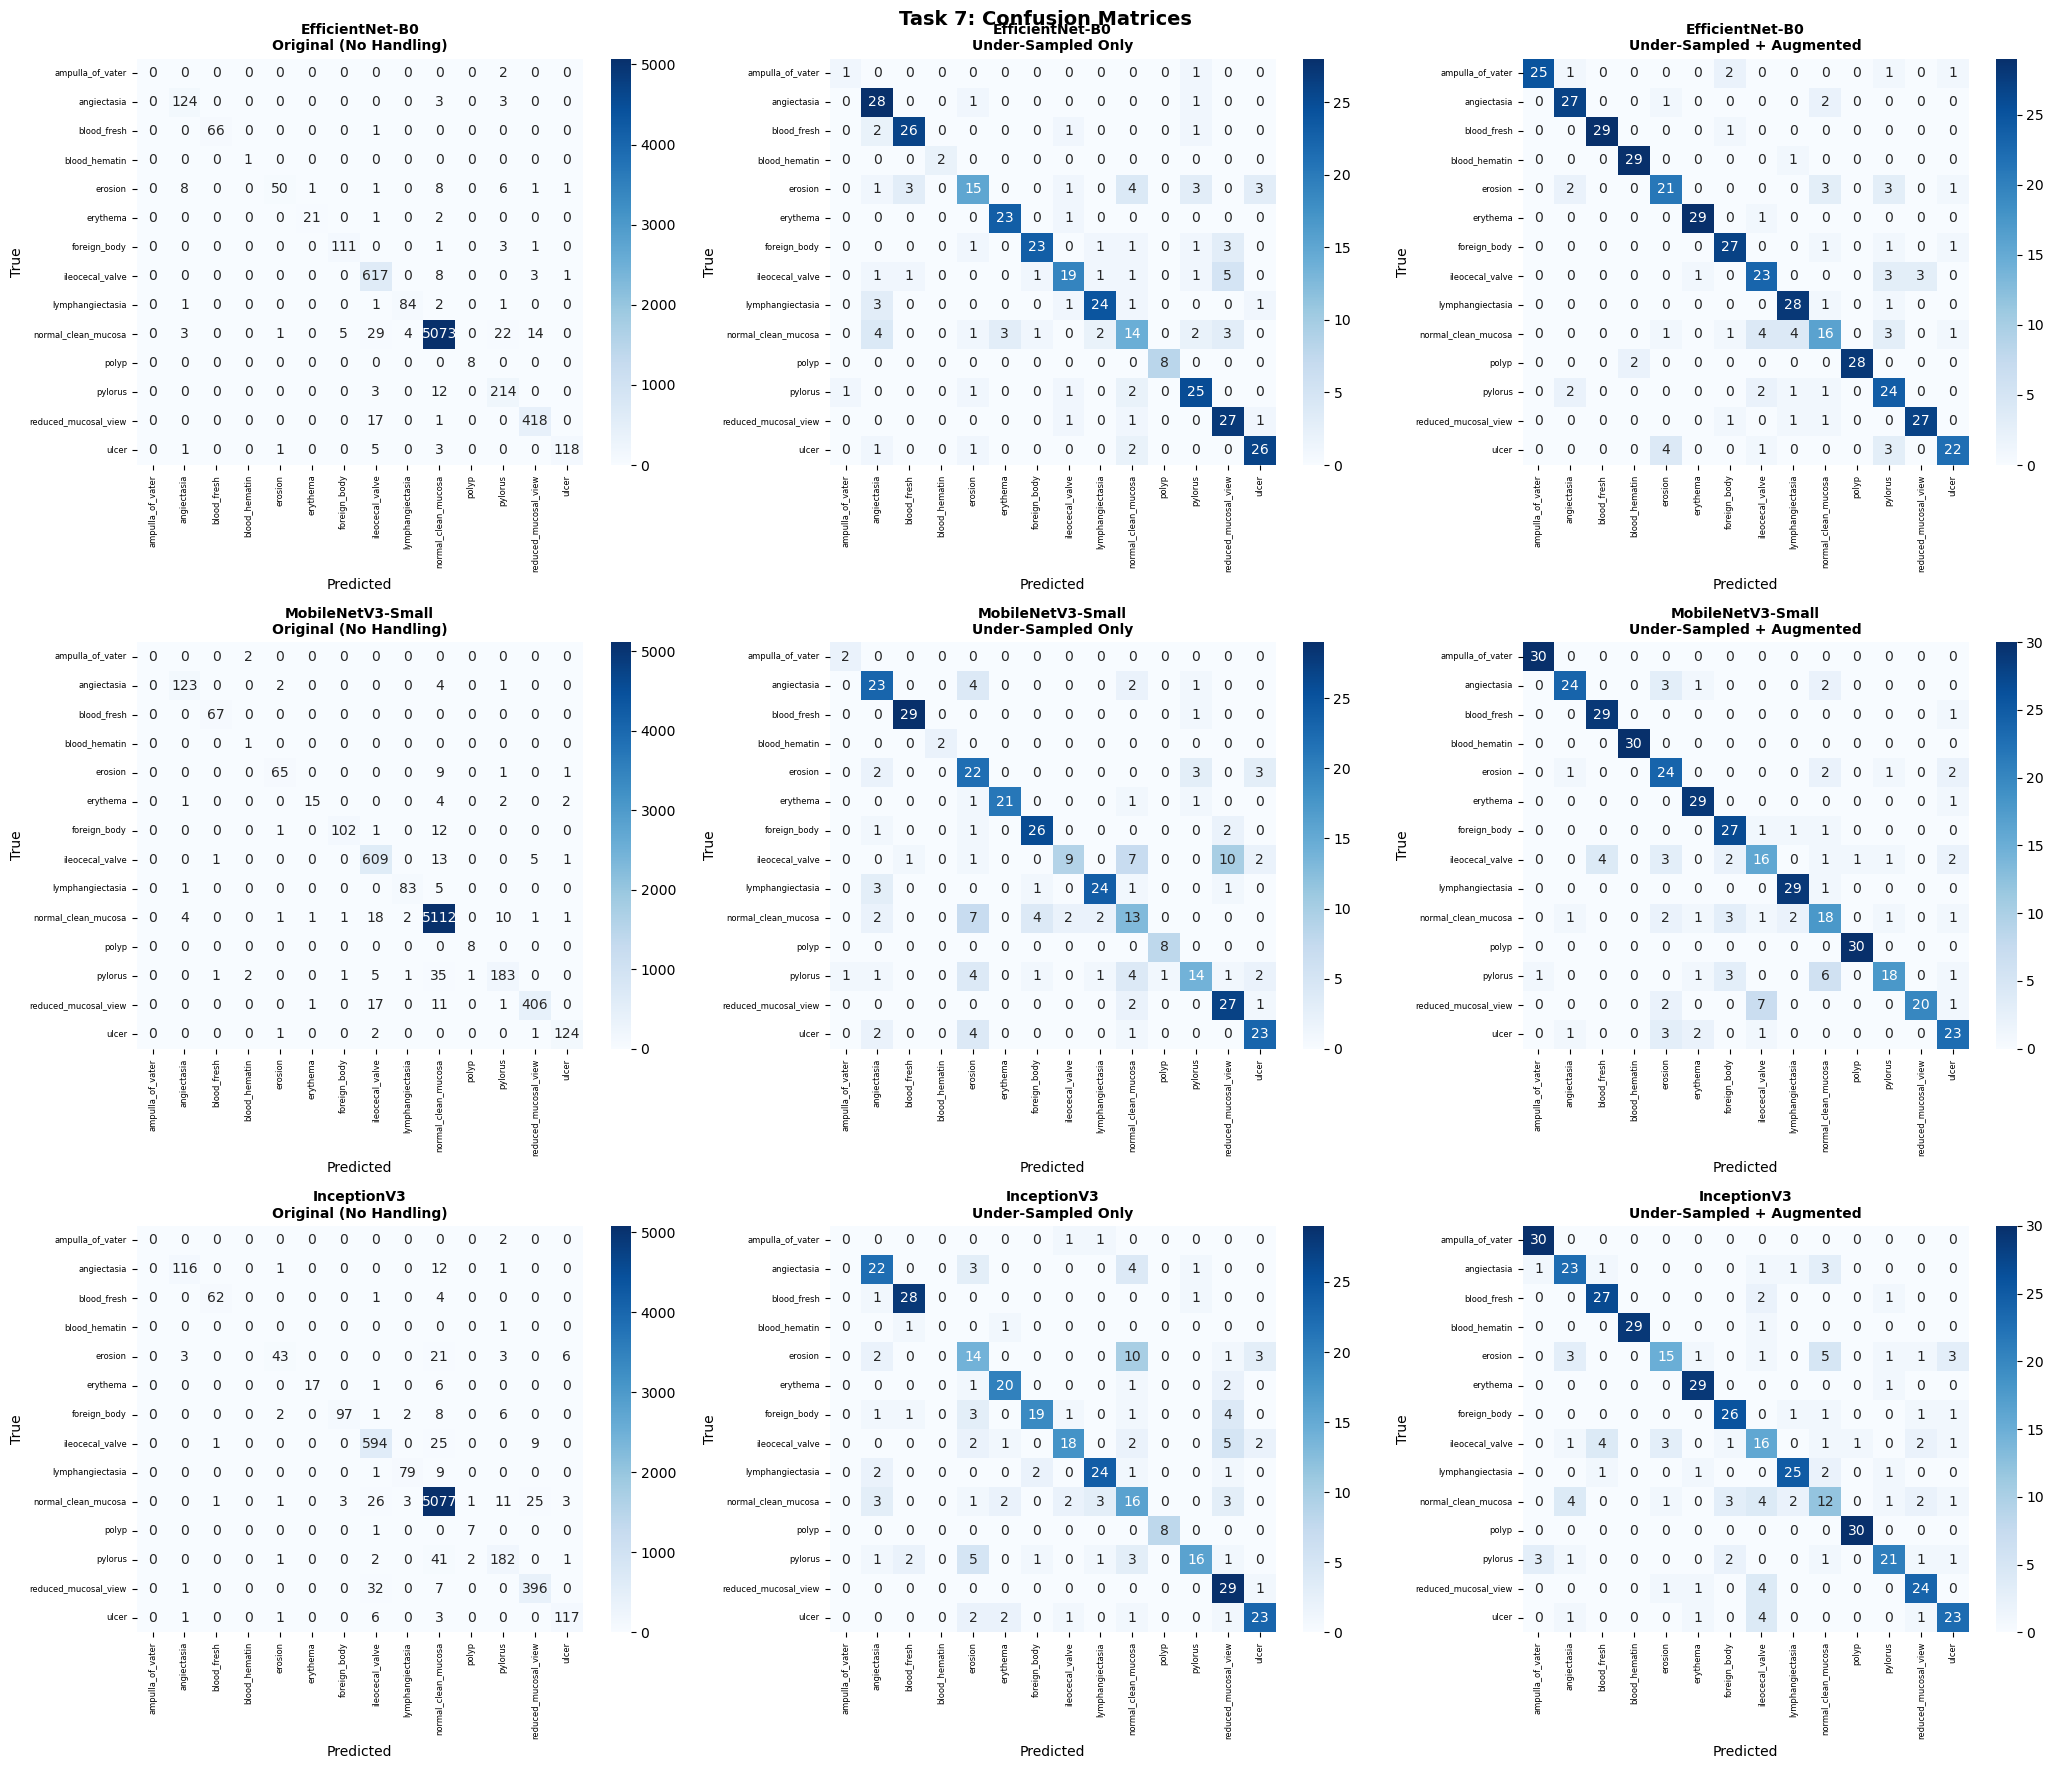

In [26]:
# ============================================================
# Task 7: Confusion Matrices
# ============================================================

fig, axes = plt.subplots(len(model_names_list), len(setting_names_list),
                         figsize=(7 * len(setting_names_list), 6 * len(model_names_list)))

for i, model_name in enumerate(model_names_list):
    for j, setting_name in enumerate(setting_names_list):
        ax = axes[i][j] if len(model_names_list) > 1 else axes[j]
        r = all_results[(model_name, setting_name)]
        cm = confusion_matrix(r['labels'], r['preds'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=[idx_to_class[k] for k in range(num_classes)],
                    yticklabels=[idx_to_class[k] for k in range(num_classes)])
        ax.set_title(f'{model_name}\n{setting_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.tick_params(axis='both', labelsize=6)

plt.suptitle('Task 7: Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# Task 7: Detailed Classification Reports
# ============================================================

for (model_name, setting_name), result in all_results.items():
    print('\n' + '=' * 70)
    print(f'{model_name} | {setting_name}')
    print('=' * 70)
    target_names = [idx_to_class[i] for i in range(num_classes)]
    print(classification_report(
        result['labels'], result['preds'],
        target_names=target_names, zero_division=0
    ))


EfficientNet-B0 | Original (No Handling)
                      precision    recall  f1-score   support

    ampulla_of_vater       0.00      0.00      0.00         2
         angiectasia       0.91      0.95      0.93       130
         blood_fresh       1.00      0.99      0.99        67
       blood_hematin       1.00      1.00      1.00         1
             erosion       0.96      0.66      0.78        76
            erythema       0.95      0.88      0.91        24
        foreign_body       0.96      0.96      0.96       116
     ileocecal_valve       0.91      0.98      0.95       629
    lymphangiectasia       0.95      0.94      0.95        89
 normal_clean_mucosa       0.99      0.98      0.99      5151
               polyp       1.00      1.00      1.00         8
             pylorus       0.85      0.93      0.89       229
reduced_mucosal_view       0.96      0.96      0.96       436
               ulcer       0.98      0.92      0.95       128

            accuracy      

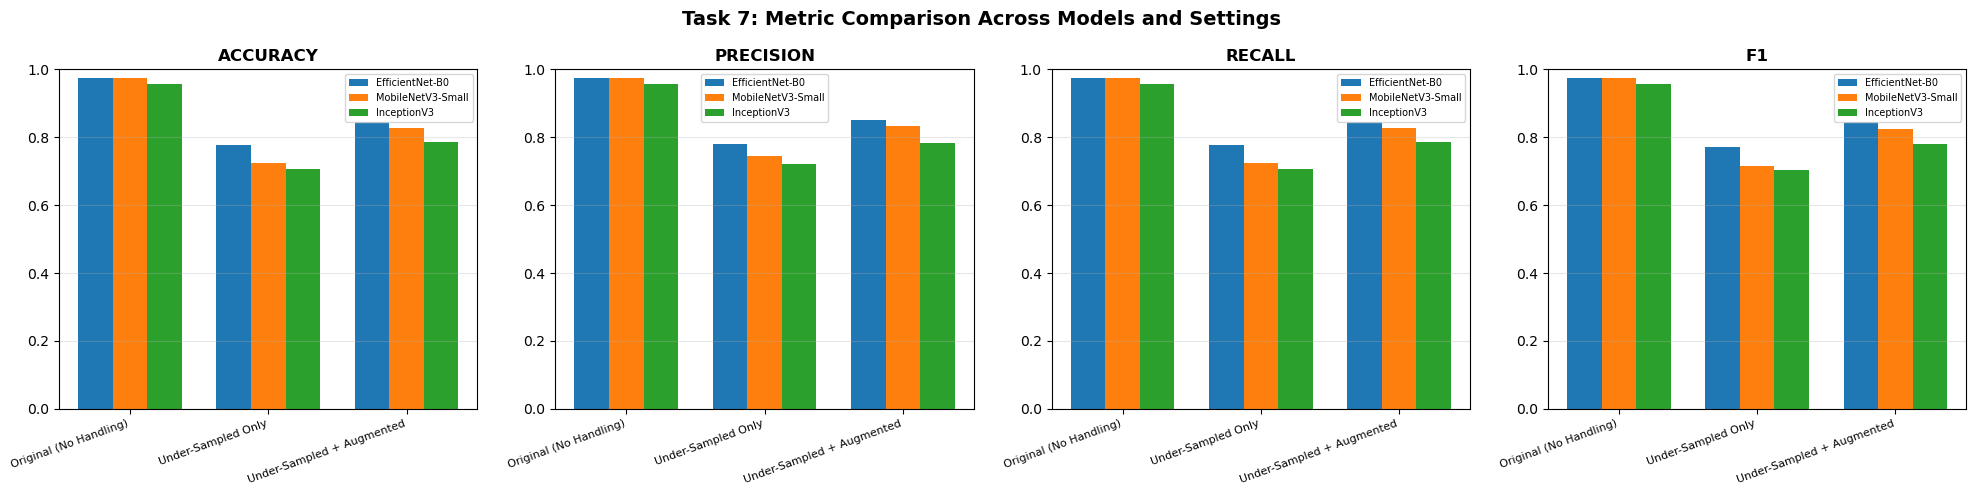

In [28]:
# ============================================================
# Task 7: Grouped Bar Chart Comparison
# ============================================================

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 5))

x = np.arange(len(setting_names_list))
width = 0.25

for k, metric in enumerate(metrics_to_plot):
    for i, model_name in enumerate(model_names_list):
        values = [all_results[(model_name, sn)]['metrics'][metric] for sn in setting_names_list]
        axes[k].bar(x + i * width, values, width, label=model_name)

    axes[k].set_xticks(x + width)
    axes[k].set_xticklabels(setting_names_list, rotation=20, ha='right', fontsize=8)
    axes[k].set_title(metric.upper(), fontweight='bold')
    axes[k].set_ylim(0, 1)
    axes[k].legend(fontsize=7)
    axes[k].grid(axis='y', alpha=0.3)

plt.suptitle('Task 7: Metric Comparison Across Models and Settings',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis and Observations (Task 7)

### 1) Overall Ranking from Final Metrics
Based on the final comparison table, the best overall run is:
- **EfficientNet-B0 + Original (No Handling)** with **F1 = 0.9743**.

The remaining original-setting runs are also strong:
- **MobileNetV3-Small + Original (No Handling):** F1 = 0.9730
- **InceptionV3 + Original (No Handling):** F1 = 0.9567

For the imbalance-handled settings:
- **Under-Sampled Only:** best is **EfficientNet-B0** with **F1 = 0.7714**.
- **Under-Sampled + Augmented:** best is **EfficientNet-B0** with **F1 = 0.8452**.

### 2) Effect of Imbalance Handling
The results show a clear pattern:
- Moving from **Original -> Under-Sampled Only** causes a large performance drop for all three models.
- Adding controlled augmentation improves results compared to under-sampling alone.
- Even after augmentation, the handled settings still remain below the original-setting performance in this experiment.

Approximate F1 change by model:
- **EfficientNet-B0:** 0.9743 -> 0.7714 -> 0.8452
- **MobileNetV3-Small:** 0.9730 -> 0.7159 -> 0.8234
- **InceptionV3:** 0.9567 -> 0.7023 -> 0.7810

### 3) Learning Rate Control Behavior
The LR-vs-epoch plots still show nearly the same pattern across all runs because the controller uses the same cosine warm-restart setup and the same plateau settings for every model.

- LR starts near **1e-3**.
- It drops around epoch 3.
- It rises again after the cosine restart.
- It then decreases again near the end.

So the LR curves are similar by design, while the final performance differences come from the model and dataset setting, not from a different LR schedule.

### 4) Training vs Validation Loss Interpretation
From the loss curves:
- All models learn quickly in the first few epochs, which is expected for transfer learning.
- The original dataset gives the smoothest and strongest convergence.
- The under-sampled settings converge more slowly and end at higher loss, which matches their lower test scores.
- Augmentation helps recover some of the lost performance, especially for EfficientNet-B0.

### 5) Confusion Matrix Insights
From the confusion matrices:
- **Original setting:** strongest diagonal and fewest misclassifications.
- **Under-Sampled Only:** more off-diagonal confusion, showing that removing data reduced class separation.
- **Under-Sampled + Augmented:** better diagonal than under-sampling alone, but still not as clean as the original setting.

### 6) Practical Conclusion
For this 5-epoch experiment:
- **Best final choice overall:** **EfficientNet-B0 on Original data**.
- If imbalance handling is required, **EfficientNet-B0 + Under-Sampled + Augmented** gives the best recovery among the handled settings.
- More gains may come from longer training, class-weighted loss, or focal loss if minority sensitivity is the priority.

In [29]:
# ============================================================
# Final Summary
# ============================================================

print('=' * 70)
print('FINAL SUMMARY')
print('=' * 70)

# Find best combination by F1-score
best_key = max(all_results, key=lambda k: all_results[k]['metrics']['f1'])
best = all_results[best_key]['metrics']

print(f'\nBest Model:   {best_key[0]}')
print(f'Best Setting: {best_key[1]}')
print(f'\n  Accuracy:  {best["accuracy"]:.4f}')
print(f'  Precision: {best["precision"]:.4f}')
print(f'  Recall:    {best["recall"]:.4f}')
print(f'  F1-Score:  {best["f1"]:.4f}')

print('\n' + '=' * 70)
print('Complete comparison table:')
print('=' * 70)
print(comparison_df.to_string(index=False))
print('\nAll tasks complete.')

FINAL SUMMARY

Best Model:   EfficientNet-B0
Best Setting: Original (No Handling)

  Accuracy:  0.9745
  Precision: 0.9751
  Recall:    0.9745
  F1-Score:  0.9743

Complete comparison table:
            Model                   Setting  Accuracy  Precision   Recall  F1-Score
  EfficientNet-B0    Original (No Handling)  0.974457   0.975079 0.974457  0.974251
MobileNetV3-Small    Original (No Handling)  0.973469   0.973401 0.973469  0.973015
      InceptionV3    Original (No Handling)  0.957804   0.957138 0.957804  0.956730
  EfficientNet-B0        Under-Sampled Only  0.776786   0.779478 0.776786  0.771429
MobileNetV3-Small        Under-Sampled Only  0.723214   0.743811 0.723214  0.715928
      InceptionV3        Under-Sampled Only  0.705357   0.721363 0.705357  0.702277
  EfficientNet-B0 Under-Sampled + Augmented  0.845238   0.850779 0.845238  0.845196
MobileNetV3-Small Under-Sampled + Augmented  0.826190   0.832454 0.826190  0.823449
      InceptionV3 Under-Sampled + Augmented  0.785714